**Install Libraries**

In [0]:
%pip install boto3 pandas numpy matplotlib seaborn pyarrow scikit-learn mlflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 106.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 601.2/601.2 kB 16.5 MB/s eta 0:00:00
  Attempting uninstall: blinker
    Found existing installation: blinker 1.7.0
    Not uninstalling blinker at /usr/lib/python3/dist-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-5a26dbff-ed8e-4950-870c-2c0c2a949072
    Can't uninstall 'blinker'. No files were found to uninstall.
  Attempting uninstall: mlflow-skinny
    Found existing installation: mlflow-skinny 3.8.1
    Not uninstalling mlflow-skinny at /databricks/python3/lib/python3.12/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-5a26dbff-ed8e-4950-870c-2c0c2a949072
    Can't uninstall '

**Import Libraries**

In [0]:
import os
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import io
import warnings
warnings.filterwarnings('ignore')

import mlflow
from sklearn.cluster      import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics      import silhouette_score

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows",    20)
pd.set_option("display.width",       1000)

print("All libraries imported successfully!")

All libraries imported successfully!


**Connect to S3 and Load All Data**

In [0]:
# ============================================================
# Load all cleaned data from S3
# ============================================================

from dotenv import load_dotenv
load_dotenv("/Workspace/Users/hsp498.ca@gmail.com/.env")
# AWS Credentials — used for Excel file reads only
ACCESS_KEY = os.getenv("ACCESS_KEY")
SECRET_KEY  = os.getenv("SECRET_KEY")
BUCKET      = os.getenv("BUCKET")
REGION      = os.getenv("REGION")

s3 = boto3.client(
    's3',
    aws_access_key_id     = ACCESS_KEY,
    aws_secret_access_key = SECRET_KEY,
    region_name           = REGION
)

# Load retail data
print("Loading cleaned retail data...")
obj          = s3.get_object(Bucket=BUCKET, Key="processed/retail_clean.parquet")
retail_clean = pd.read_parquet(io.BytesIO(obj['Body'].read()))
retail_clean['InvoiceDate'] = pd.to_datetime(retail_clean['InvoiceDate'])

# Load survival data from Module 2
print("Loading survival data...")
obj           = s3.get_object(Bucket=BUCKET, Key="outputs/customer_survival_data.parquet")
survival_data = pd.read_parquet(io.BytesIO(obj['Body'].read()))

# Load sentiment data from Module 3
print("Loading sentiment data...")
obj              = s3.get_object(Bucket=BUCKET, Key="outputs/reviews_with_sentiment.parquet")
sentiment_data   = pd.read_parquet(io.BytesIO(obj['Body'].read()))

# Load recommendations from Module 1
print("Loading recommendations data...")
obj      = s3.get_object(Bucket=BUCKET, Key="outputs/all_customer_recommendations.parquet")
recs_data = pd.read_parquet(io.BytesIO(obj['Body'].read()))

print(f"\nRetail data    : {len(retail_clean):,} rows")
print(f"Survival data  : {len(survival_data):,} rows")
print(f"Sentiment data : {len(sentiment_data):,} rows")
print(f"Recs data      : {len(recs_data):,} rows")
print("\nAll data loaded successfully!")

Loading cleaned retail data...
Loading survival data...
Loading sentiment data...
Loading recommendations data...

Retail data    : 805,549 rows
Survival data  : 5,878 rows
Sentiment data : 560,777 rows
Recs data      : 29,390 rows

All data loaded successfully!


**RFM Analysis (Recency, Frequency, Monetary)**

In [0]:
# ============================================================
# RFM Analysis — Fixed for duplicate bin edges
# ============================================================

print("Running RFM Analysis...\n")

reference_date = retail_clean['InvoiceDate'].max()

# Calculate RFM metrics per customer
rfm = retail_clean.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate',  lambda x: (reference_date - x.max()).days),
    Frequency = ('Invoice',      'nunique'),
    Monetary  = ('TotalSpend',   'sum')
).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print(f"Total customers : {len(rfm):,}")
print(f"\nRFM Distribution:")
print(rfm[['Recency','Frequency','Monetary']].describe().round(2).to_string())

# ── Safe scoring function ──────────────────────────────────
# Uses rank-based percentile instead of qcut
# Works even when many customers have identical values

def safe_rfm_score(series, reverse=False):
    """
    Score a series from 1 to 5 using percentile rank.
    reverse=True means lower value = higher score (used for Recency)
    """
    pct = series.rank(pct=True)
    if reverse:
        pct = 1 - pct
    score = pd.cut(
        pct,
        bins   = [0, 0.2, 0.4, 0.6, 0.8, 1.0],
        labels = [1, 2, 3, 4, 5],
        include_lowest = True
    ).astype(int)
    return score

# Apply safe scoring
rfm['R_Score'] = safe_rfm_score(rfm['Recency'],   reverse=True)
rfm['F_Score'] = safe_rfm_score(rfm['Frequency'],  reverse=False)
rfm['M_Score'] = safe_rfm_score(rfm['Monetary'],   reverse=False)

# Combined RFM Score (3 = worst, 15 = best)
rfm['RFM_Score'] = (
    rfm['R_Score'] +
    rfm['F_Score'] +
    rfm['M_Score']
)

# Segment customers based on RFM score
def rfm_segment(score):
    if score >= 13:
        return 'Champions'
    elif score >= 10:
        return 'Loyal Customers'
    elif score >= 7:
        return 'At Risk'
    else:
        return 'Lost'

rfm['RFM_Segment'] = rfm['RFM_Score'].apply(rfm_segment)

print(f"\n=== RFM Scores Summary ===")
print(rfm[['R_Score','F_Score','M_Score','RFM_Score']].describe().round(2).to_string())

print(f"\n=== Customer Segments ===")
seg_counts = rfm['RFM_Segment'].value_counts()
seg_pct    = (rfm['RFM_Segment'].value_counts(normalize=True) * 100).round(1)
seg_df     = pd.DataFrame({'Count': seg_counts, 'Percentage %': seg_pct})
print(seg_df.to_string())

print(f"\nSample RFM data:")
print(rfm.head(8).to_string())

Running RFM Analysis...

Total customers : 5,878

RFM Distribution:
       Recency  Frequency   Monetary
count  5878.00    5878.00    5878.00
mean    200.33       6.29    3018.62
std     209.34      13.01   14737.73
min       0.00       1.00       2.95
25%      25.00       1.00     348.76
50%      95.00       3.00     898.92
75%     379.00       7.00    2307.09
max     738.00     398.00  608821.65

=== RFM Scores Summary ===
       R_Score  F_Score  M_Score  RFM_Score
count  5878.00  5878.00  5878.00    5878.00
mean      3.00     2.85     3.00       8.85
std       1.42     1.48     1.41       3.73
min       1.00     1.00     1.00       3.00
25%       2.00     1.00     2.00       6.00
50%       3.00     3.00     3.00       9.00
75%       4.00     4.00     4.00      12.00
max       5.00     5.00     5.00      15.00

=== Customer Segments ===
                 Count  Percentage %
RFM_Segment                         
Lost              1886          32.1
At Risk           1406          23.9


**K-Means Clustering on RFM**

In [0]:
# ============================================================
# K-Means Clustering on RFM Features
# Groups customers into 4 distinct behaviour clusters
# ============================================================

print("Running K-Means clustering on RFM features...\n")

# Prepare features
features     = ['Recency', 'Frequency', 'Monetary']
rfm_features = rfm[features].copy()

# Scale features (important for K-Means)
scaler           = StandardScaler()
rfm_scaled       = scaler.fit_transform(rfm_features)
rfm_scaled_df    = pd.DataFrame(rfm_scaled, columns=features)

# Find optimal number of clusters using elbow method
print("Finding optimal clusters (elbow method)...")
inertias    = []
sil_scores  = []
k_range     = range(2, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, kmeans.labels_))
    print(f"  k={k} | Inertia={kmeans.inertia_:.0f} | Silhouette={sil_scores[-1]:.4f}")

# Use k=4 (matches our business segments)
print("\nUsing k=4 clusters for business interpretability...")
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled)

# Label clusters based on their RFM profile
cluster_profile = rfm.groupby('Cluster')[features].mean().round(2)
print("\nCluster Profiles (raw averages):")
print(cluster_profile.to_string())

# Assign business labels to clusters
# Low recency + high frequency + high monetary = Champions
cluster_labels = {}
for cluster in range(4):
    profile = cluster_profile.loc[cluster]
    if profile['Recency'] < cluster_profile['Recency'].median():
        if profile['Monetary'] > cluster_profile['Monetary'].median():
            cluster_labels[cluster] = 'Champions'
        else:
            cluster_labels[cluster] = 'Loyal Customers'
    else:
        if profile['Monetary'] > cluster_profile['Monetary'].median():
            cluster_labels[cluster] = 'At Risk'
        else:
            cluster_labels[cluster] = 'Lost Customers'

rfm['Cluster_Label'] = rfm['Cluster'].map(cluster_labels)

print("\nFinal Cluster Assignments:")
print(rfm['Cluster_Label'].value_counts().to_string())

Running K-Means clustering on RFM features...

Finding optimal clusters (elbow method)...
  k=2 | Inertia=12115 | Silhouette=0.9164
  k=3 | Inertia=7124 | Silhouette=0.5804
  k=4 | Inertia=5166 | Silhouette=0.5905
  k=5 | Inertia=3910 | Silhouette=0.6004
  k=6 | Inertia=3304 | Silhouette=0.5495
  k=7 | Inertia=2737 | Silhouette=0.5494
  k=8 | Inertia=2254 | Silhouette=0.5407

Using k=4 clusters for business interpretability...

Cluster Profiles (raw averages):
         Recency  Frequency   Monetary
Cluster                               
0         462.03       2.21     765.24
1          66.01       7.31    3009.40
2          24.94     103.71   83086.08
3           2.50     212.50  436835.79

Final Cluster Assignments:
Cluster_Label
Lost Customers    5839
Champions           39


**RFM Visualization**

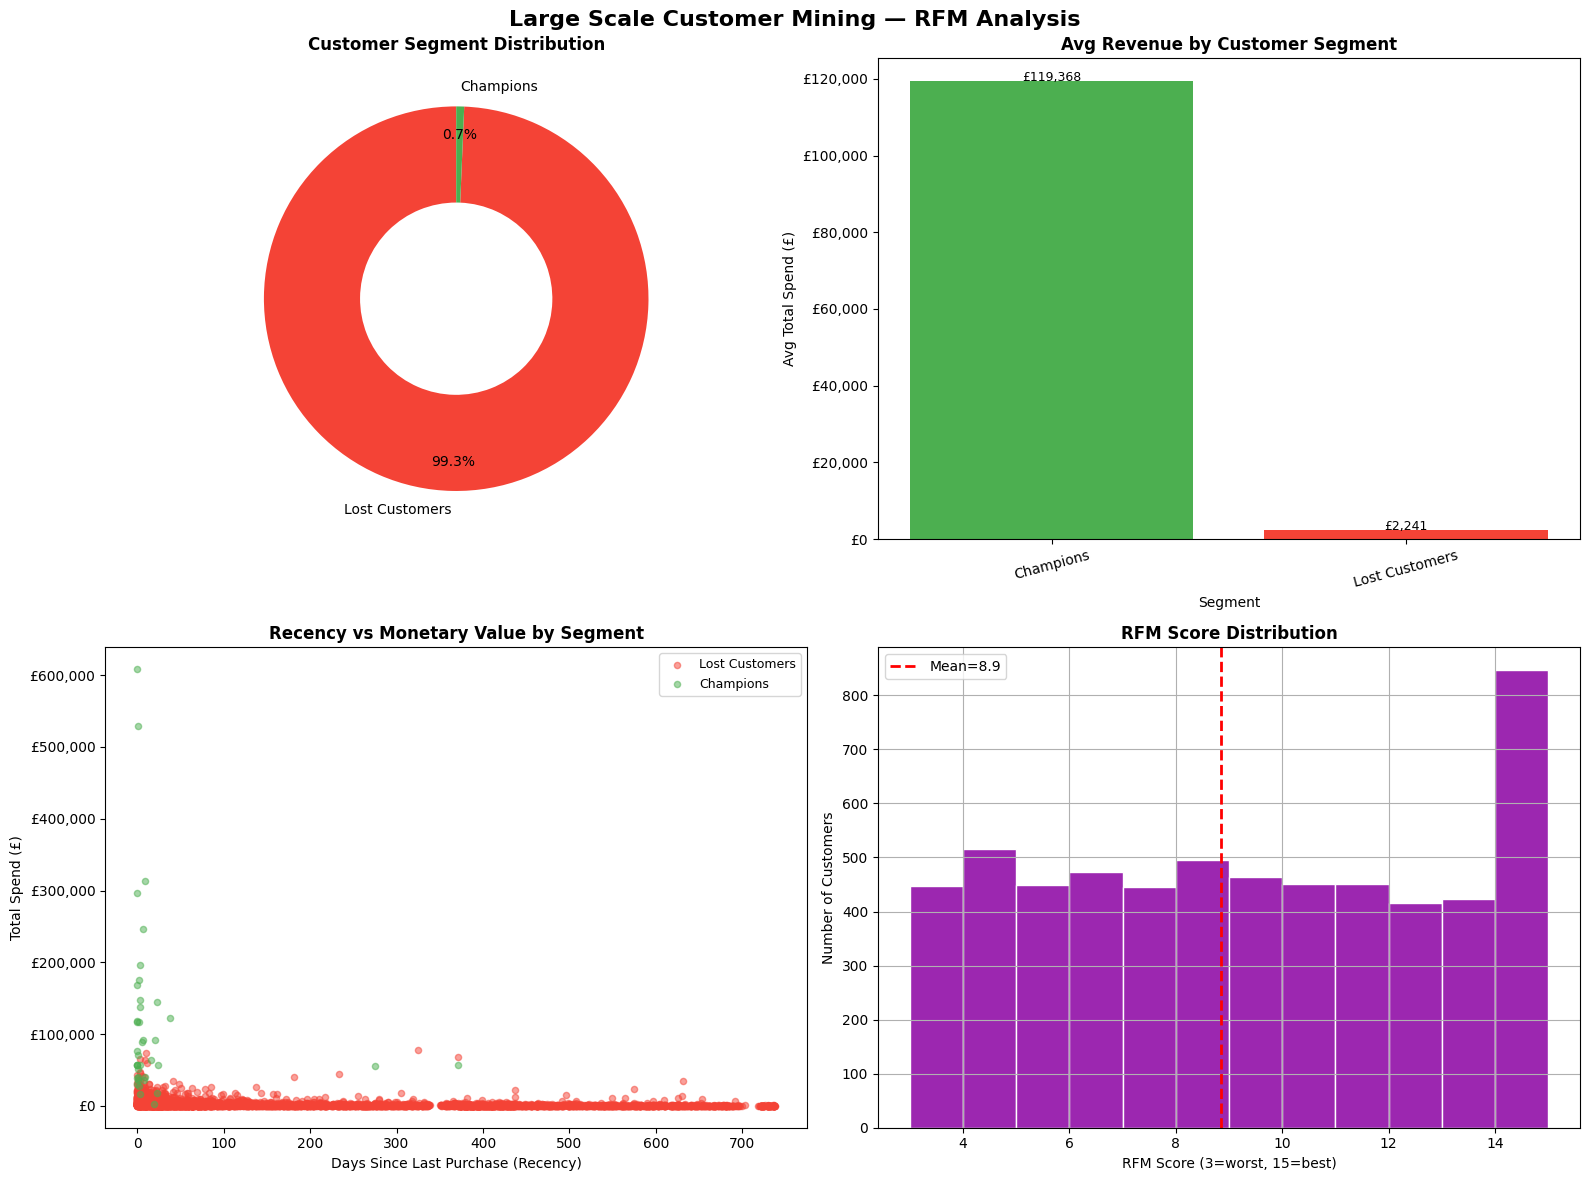

RFM visualization complete!


In [0]:
# ============================================================
# RFM Visualizations — 4 business charts
# ============================================================

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig)
fig.suptitle(
    'Large Scale Customer Mining — RFM Analysis',
    fontsize=16, fontweight='bold'
)

colors_seg = {
    'Champions'      : '#4CAF50',
    'Loyal Customers': '#2196F3',
    'At Risk'        : '#FF9800',
    'Lost Customers' : '#F44336',
    'Lost'           : '#F44336'
}

# Chart 1 — Customer segment distribution (donut chart)
ax1  = fig.add_subplot(gs[0, 0])
seg_data   = rfm['Cluster_Label'].value_counts()
seg_colors = [colors_seg.get(s, '#999999') for s in seg_data.index]
wedges, texts, autotexts = ax1.pie(
    seg_data.values,
    labels      = seg_data.index,
    colors      = seg_colors,
    autopct     = '%1.1f%%',
    startangle  = 90,
    pctdistance = 0.85,
    wedgeprops  = dict(width=0.5)
)
for text in autotexts:
    text.set_fontsize(10)
ax1.set_title('Customer Segment Distribution', fontweight='bold', fontsize=12)

# Chart 2 — Average monetary value by segment
ax2        = fig.add_subplot(gs[0, 1])
seg_monetary = rfm.groupby('Cluster_Label')['Monetary'].mean().sort_values(ascending=False)
bar_colors   = [colors_seg.get(s, '#999999') for s in seg_monetary.index]
bars = ax2.bar(seg_monetary.index, seg_monetary.values, color=bar_colors)
ax2.set_title('Avg Revenue by Customer Segment', fontweight='bold', fontsize=12)
ax2.set_xlabel('Segment')
ax2.set_ylabel('Avg Total Spend (£)')
ax2.tick_params(axis='x', rotation=15)
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'£{x:,.0f}')
)
for bar, val in zip(bars, seg_monetary.values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,
             f'£{val:,.0f}', ha='center', fontsize=9)

# Chart 3 — Recency vs Monetary scatter
ax3 = fig.add_subplot(gs[1, 0])
for segment in rfm['Cluster_Label'].unique():
    mask = rfm['Cluster_Label'] == segment
    ax3.scatter(
        rfm.loc[mask, 'Recency'],
        rfm.loc[mask, 'Monetary'],
        c     = colors_seg.get(segment, '#999999'),
        label = segment,
        alpha = 0.5,
        s     = 20
    )
ax3.set_title('Recency vs Monetary Value by Segment',
              fontweight='bold', fontsize=12)
ax3.set_xlabel('Days Since Last Purchase (Recency)')
ax3.set_ylabel('Total Spend (£)')
ax3.legend(fontsize=9)
ax3.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'£{x:,.0f}')
)

# Chart 4 — RFM Score distribution
ax4 = fig.add_subplot(gs[1, 1])
rfm['RFM_Score'].hist(bins=12, ax=ax4, color='#9C27B0', edgecolor='white')
ax4.set_title('RFM Score Distribution', fontweight='bold', fontsize=12)
ax4.set_xlabel('RFM Score (3=worst, 15=best)')
ax4.set_ylabel('Number of Customers')
ax4.axvline(x=rfm['RFM_Score'].mean(), color='red',
            linestyle='--', linewidth=2,
            label=f"Mean={rfm['RFM_Score'].mean():.1f}")
ax4.legend()

plt.tight_layout()
plt.savefig('/tmp/rfm_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("RFM visualization complete!")

**Combine All 4 Modules Into Master Dataset**

In [0]:
# ============================================================
# MASTER DATASET — Combine all 4 modules
# This is the key integration step that links everything
# ============================================================

print("Building master customer dataset...\n")
print("Combining outputs from all 4 modules:")
print("  Module 1 — Recommendation scores")
print("  Module 2 — Survival / churn data")
print("  Module 3 — Sentiment scores")
print("  Module 4 — RFM segments\n")

# Start with RFM data as base
master = rfm[['CustomerID','Recency','Frequency','Monetary',
              'RFM_Score','RFM_Segment','Cluster_Label']].copy()

# Merge survival data from Module 2
survival_merge = survival_data[[
    'Customer ID','duration','churned',
    'total_orders','avg_order_value',
    'days_since_last','segment'
]].rename(columns={'Customer ID': 'CustomerID'})

master = master.merge(survival_merge, on='CustomerID', how='left')

# Merge recommendation scores from Module 1
recs_merge = recs_data.groupby('CustomerID').agg(
    avg_rec_score    = ('Score', 'mean'),
    top_rec_product  = ('Description', 'first')
).reset_index()

master = master.merge(recs_merge, on='CustomerID', how='left')

print(f"Master dataset shape     : {master.shape}")
print(f"Columns                  : {list(master.columns)}")
print(f"\nMaster dataset sample:")
print(master.head(5).to_string())

Building master customer dataset...

Combining outputs from all 4 modules:
  Module 1 — Recommendation scores
  Module 2 — Survival / churn data
  Module 3 — Sentiment scores
  Module 4 — RFM segments

Master dataset shape     : (5878, 15)
Columns                  : ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'RFM_Score', 'RFM_Segment', 'Cluster_Label', 'duration', 'churned', 'total_orders', 'avg_order_value', 'days_since_last', 'segment', 'avg_rec_score', 'top_rec_product']

Master dataset sample:
   CustomerID  Recency  Frequency  Monetary  RFM_Score      RFM_Segment   Cluster_Label  duration  churned  total_orders  avg_order_value  days_since_last       segment  avg_rec_score                   top_rec_product
0       12346      325         12  77556.46         12  Loyal Customers  Lost Customers       400        1            12      2281.072353              325    High Value        65.4582                     PARTY BUNTING
1       12347        1          8   5633.32         1

**Business Intelligence Summary**

In [0]:
# ============================================================
# Business Intelligence Summary
# The complete picture of your customer lifecycle
# ============================================================

print("=" * 60)
print("COMPLETE CUSTOMER LIFECYCLE — BUSINESS INTELLIGENCE REPORT")
print("=" * 60)

# Segment summary with all metrics
segment_summary = master.groupby('Cluster_Label').agg(
    customer_count   = ('CustomerID',       'count'),
    avg_recency      = ('Recency',          'mean'),
    avg_frequency    = ('Frequency',        'mean'),
    avg_monetary     = ('Monetary',         'mean'),
    total_revenue    = ('Monetary',         'sum'),
    churn_rate       = ('churned',          'mean'),
    avg_tenure_days  = ('duration',         'mean'),
    avg_order_value  = ('avg_order_value',  'mean')
).round(2)

segment_summary['churn_rate_pct'] = (
    segment_summary['churn_rate'] * 100
).round(1)
segment_summary['revenue_share_pct'] = (
    segment_summary['total_revenue'] /
    segment_summary['total_revenue'].sum() * 100
).round(1)

print("\nSegment Summary Table:")
print(segment_summary[[
    'customer_count','avg_recency','avg_frequency',
    'avg_monetary','churn_rate_pct','revenue_share_pct'
]].to_string())

# Key business metrics
total_revenue   = master['Monetary'].sum()
total_customers = len(master)
churn_rate      = master['churned'].mean() * 100

print(f"\n{'='*60}")
print(f"KEY BUSINESS METRICS")
print(f"{'='*60}")
print(f"Total customers          : {total_customers:,}")
print(f"Total revenue            : £{total_revenue:,.2f}")
print(f"Overall churn rate       : {churn_rate:.1f}%")
print(f"Avg revenue per customer : £{total_revenue/total_customers:,.2f}")
print(f"Revenue from Champions   : £{segment_summary.loc['Champions','total_revenue']:,.2f}" 
      if 'Champions' in segment_summary.index else "")

COMPLETE CUSTOMER LIFECYCLE — BUSINESS INTELLIGENCE REPORT

Segment Summary Table:
                customer_count  avg_recency  avg_frequency  avg_monetary  churn_rate_pct  revenue_share_pct
Cluster_Label                                                                                              
Champions                   39        22.64         114.87     119368.10             5.0               26.2
Lost Customers            5839       201.52           5.56       2241.49            51.0               73.8

KEY BUSINESS METRICS
Total customers          : 5,878
Total revenue            : £17,743,429.18
Overall churn rate       : 50.8%
Avg revenue per customer : £3,018.62
Revenue from Champions   : £4,655,355.96


**Final Combined Business Chart**

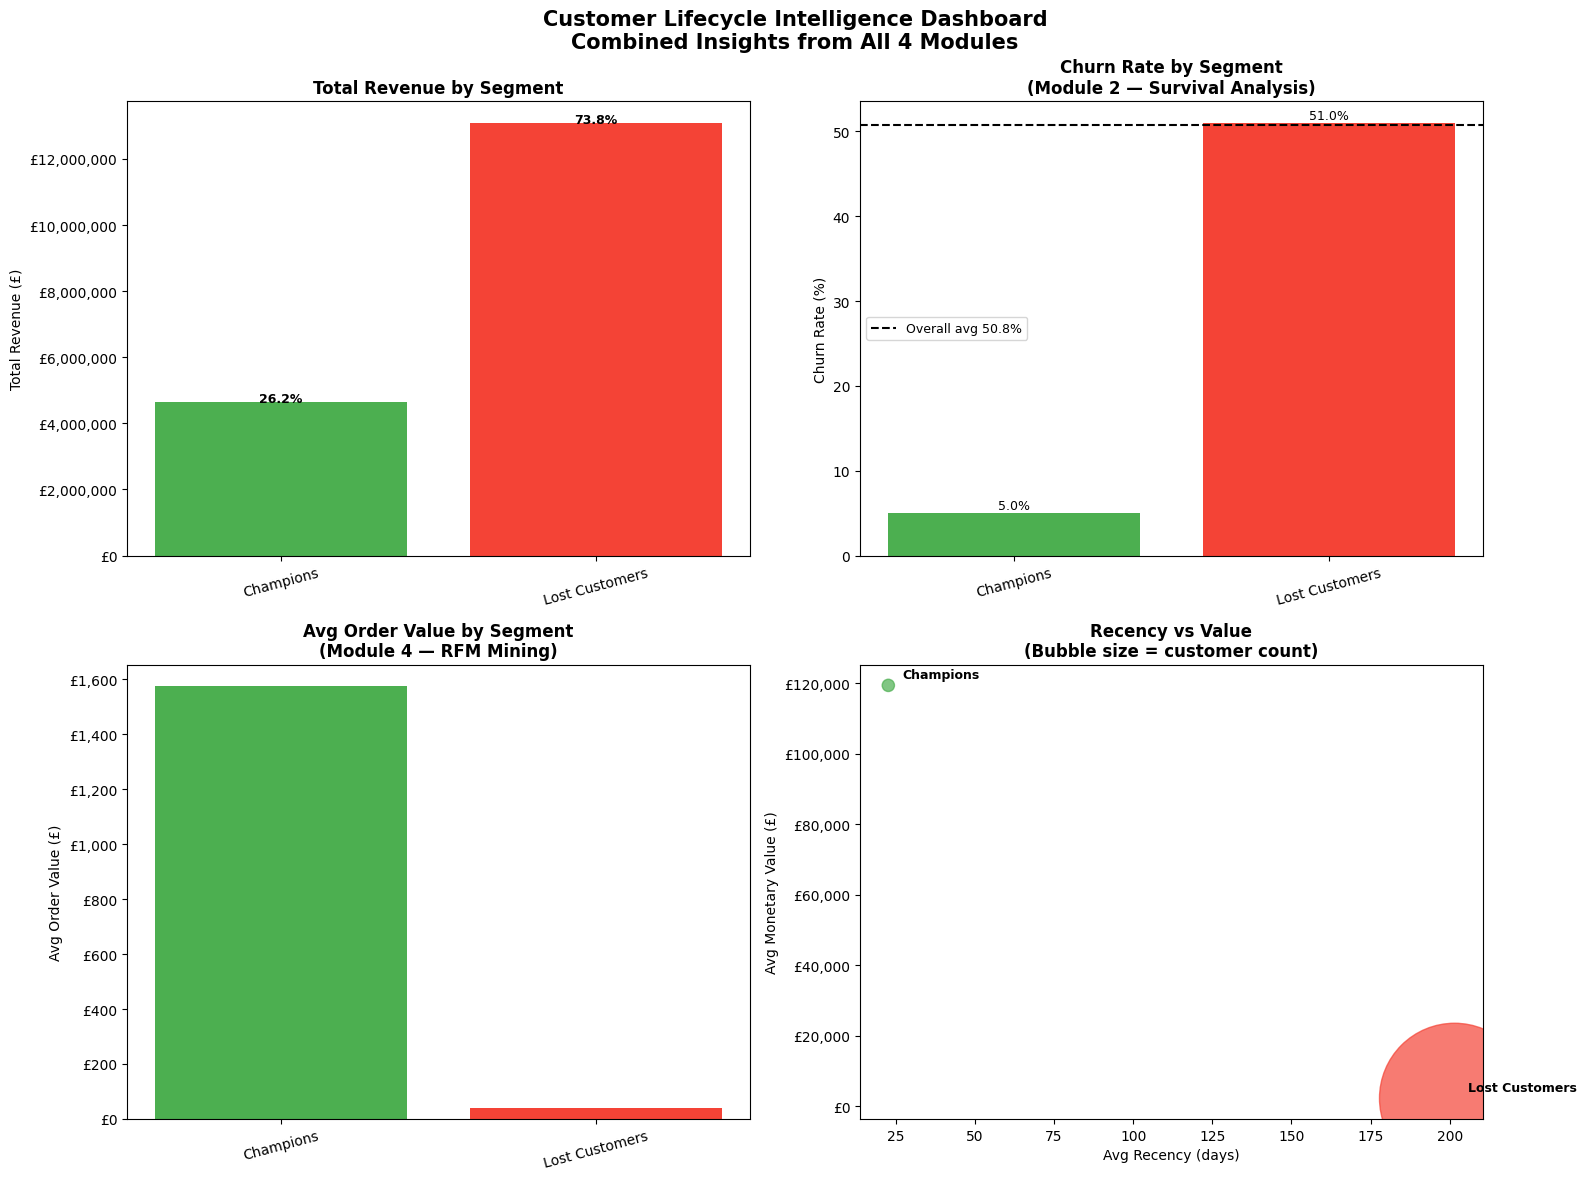

Final dashboard chart generated!


In [0]:
# ============================================================
# Final Business Dashboard Chart
# Combines insights from all 4 modules
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    'Customer Lifecycle Intelligence Dashboard\nCombined Insights from All 4 Modules',
    fontsize=15, fontweight='bold'
)

seg_colors_list = [
    colors_seg.get(s, '#999999')
    for s in segment_summary.index
]

# Chart 1 — Revenue share by segment (Module 4 + Module 2)
axes[0,0].bar(
    segment_summary.index,
    segment_summary['total_revenue'],
    color=seg_colors_list
)
axes[0,0].set_title('Total Revenue by Segment', fontweight='bold')
axes[0,0].set_ylabel('Total Revenue (£)')
axes[0,0].tick_params(axis='x', rotation=15)
axes[0,0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'£{x:,.0f}')
)
for i, (seg, row) in enumerate(segment_summary.iterrows()):
    axes[0,0].text(i, row['total_revenue'] + 1000,
                   f"{row['revenue_share_pct']}%",
                   ha='center', fontsize=9, fontweight='bold')

# Chart 2 — Churn rate by segment (Module 2)
axes[0,1].bar(
    segment_summary.index,
    segment_summary['churn_rate_pct'],
    color=seg_colors_list
)
axes[0,1].set_title('Churn Rate by Segment\n(Module 2 — Survival Analysis)',
                     fontweight='bold')
axes[0,1].set_ylabel('Churn Rate (%)')
axes[0,1].tick_params(axis='x', rotation=15)
axes[0,1].axhline(y=50.8, color='black', linestyle='--',
                   linewidth=1.5, label='Overall avg 50.8%')
axes[0,1].legend(fontsize=9)
for i, (seg, row) in enumerate(segment_summary.iterrows()):
    axes[0,1].text(i, row['churn_rate_pct'] + 0.5,
                   f"{row['churn_rate_pct']}%",
                   ha='center', fontsize=9)

# Chart 3 — Avg order value by segment (Module 4)
axes[1,0].bar(
    segment_summary.index,
    segment_summary['avg_order_value'],
    color=seg_colors_list
)
axes[1,0].set_title('Avg Order Value by Segment\n(Module 4 — RFM Mining)',
                     fontweight='bold')
axes[1,0].set_ylabel('Avg Order Value (£)')
axes[1,0].tick_params(axis='x', rotation=15)
axes[1,0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'£{x:,.0f}')
)

# Chart 4 — Customer count vs avg monetary bubble chart
axes[1,1].scatter(
    segment_summary['avg_recency'],
    segment_summary['avg_monetary'],
    s    = segment_summary['customer_count'] * 2,
    c    = seg_colors_list,
    alpha= 0.7
)
for seg, row in segment_summary.iterrows():
    axes[1,1].annotate(
        seg,
        (row['avg_recency'], row['avg_monetary']),
        textcoords = "offset points",
        xytext     = (10, 5),
        fontsize   = 9,
        fontweight = 'bold'
    )
axes[1,1].set_title('Recency vs Value\n(Bubble size = customer count)',
                     fontweight='bold')
axes[1,1].set_xlabel('Avg Recency (days)')
axes[1,1].set_ylabel('Avg Monetary Value (£)')
axes[1,1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'£{x:,.0f}')
)

plt.tight_layout()
plt.savefig('/tmp/final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Final dashboard chart generated!")

**Save Everything and Log to MLflow**

In [0]:
# ============================================================
# Save master dataset to S3 and log all metrics to MLflow
# ============================================================

mlflow.set_experiment("/ecom-project/large-scale-mining")

with mlflow.start_run(run_name="rfm_clustering_v1"):

    # Log parameters
    mlflow.log_param("n_clusters",       4)
    mlflow.log_param("clustering_method","kmeans")
    mlflow.log_param("rfm_scoring",      "quintile")
    mlflow.log_param("total_customers",  len(master))

    # Log metrics
    mlflow.log_metric("total_revenue",
                      round(master['Monetary'].sum(), 2))
    mlflow.log_metric("overall_churn_rate",
                      round(master['churned'].mean() * 100, 2))
    mlflow.log_metric("avg_revenue_per_customer",
                      round(master['Monetary'].mean(), 2))
    mlflow.log_metric("rfm_mean_score",
                      round(master['RFM_Score'].mean(), 2))

    # Log segment counts
    for seg, count in rfm['Cluster_Label'].value_counts().items():
        mlflow.log_metric(
            f"segment_{seg.lower().replace(' ','_')}", count
        )

    run_id = mlflow.active_run().info.run_id

# Save master dataset to S3
print("Saving master dataset to S3...")
master_buffer = io.BytesIO()
master.to_parquet(master_buffer, index=False)
master_buffer.seek(0)
s3.put_object(
    Bucket = BUCKET,
    Key    = "outputs/master_customer_dataset.parquet",
    Body   = master_buffer.getvalue()
)
print("Saved : outputs/master_customer_dataset.parquet")

# Save RFM data to S3
rfm_buffer = io.BytesIO()
rfm.to_parquet(rfm_buffer, index=False)
rfm_buffer.seek(0)
s3.put_object(
    Bucket = BUCKET,
    Key    = "outputs/rfm_segments.parquet",
    Body   = rfm_buffer.getvalue()
)
print("Saved : outputs/rfm_segments.parquet")

# Final S3 check — list all output files
print("\n=== All files in S3 outputs/ folder ===")
response = s3.list_objects_v2(Bucket=BUCKET, Prefix="outputs/")
for obj in response.get("Contents", []):
    size_mb = round(obj["Size"] / 1024 / 1024, 2)
    print(f"  {obj['Key']:<55} {size_mb} MB")

print(f"\nMLflow run ID : {run_id}")
print(f"\n{'='*60}")
print("MODULE 4 — LARGE SCALE MINING COMPLETE!")
print(f"{'='*60}")
print(f"Customers segmented   : {len(master):,}")
print(f"Total revenue mined   : £{master['Monetary'].sum():,.2f}")
print(f"Segments identified   : {rfm['Cluster_Label'].nunique()}")
print(f"\n{'='*60}")
print("ALL 4 MODULES COMPLETE!")
print(f"{'='*60}")
print("Module 1 — Recommendation System    DONE")
print("Module 2 — Survival Analysis        DONE")
print("Module 3 — Sentiment Analysis       DONE")
print("Module 4 — Large Scale Mining       DONE")
print(f"\nNext : Build QuickSight Dashboard")
print(f"Then : Write Technical Report")

Saving master dataset to S3...
Saved : outputs/master_customer_dataset.parquet
Saved : outputs/rfm_segments.parquet

=== All files in S3 outputs/ folder ===
  outputs/                                                0.0 MB
  outputs/all_customer_recommendations.parquet            0.36 MB
  outputs/at_risk_customers.parquet                       0.04 MB
  outputs/customer_survival_data.parquet                  0.32 MB
  outputs/master_customer_dataset.parquet                 0.24 MB
  outputs/product_sentiment.parquet                       0.32 MB
  outputs/reviews_with_sentiment.parquet                  162.32 MB
  outputs/rfm_segments.parquet                            0.1 MB

MLflow run ID : 3fe465585b5a4583a9aac7ffb5da8c64

MODULE 4 — LARGE SCALE MINING COMPLETE!
Customers segmented   : 5,878
Total revenue mined   : £17,743,429.18
Segments identified   : 2

ALL 4 MODULES COMPLETE!
Module 1 — Recommendation System    DONE
Module 2 — Survival Analysis        DONE
Module 3 — Sentiment A

In [0]:
# ============================================================
# Convert parquet outputs to CSV for QuickSight
# ============================================================

import boto3
import pandas as pd
import io

from dotenv import load_dotenv
load_dotenv("/Workspace/Users/hsp498.ca@gmail.com/.env")
# AWS Credentials — used for Excel file reads only
ACCESS_KEY = os.getenv("ACCESS_KEY")
SECRET_KEY  = os.getenv("SECRET_KEY")
BUCKET      = os.getenv("BUCKET")
REGION      = os.getenv("REGION")

s3 = boto3.client(
    's3',
    aws_access_key_id     = ACCESS_KEY,
    aws_secret_access_key = SECRET_KEY,
    region_name           = REGION
)

print("Converting parquet files to CSV for QuickSight...\n")

# ── File 1 — Master customer dataset ──────────────────────
obj    = s3.get_object(Bucket=BUCKET, Key="outputs/master_customer_dataset.parquet")
master = pd.read_parquet(io.BytesIO(obj['Body'].read()))

# Keep only columns QuickSight needs
master_qs = master[[
    'CustomerID','Recency','Frequency','Monetary',
    'RFM_Score','RFM_Segment','Cluster_Label',
    'duration','churned','total_orders',
    'avg_order_value','days_since_last','segment'
]].copy()

csv_buffer = io.StringIO()
master_qs.to_csv(csv_buffer, index=False)
s3.put_object(Bucket=BUCKET, Key="quicksight/master_customers.csv",
              Body=csv_buffer.getvalue())
print(f"Saved: quicksight/master_customers.csv ({len(master_qs):,} rows)")

# ── File 2 — RFM Segments ─────────────────────────────────
obj = s3.get_object(Bucket=BUCKET, Key="outputs/rfm_segments.parquet")
rfm = pd.read_parquet(io.BytesIO(obj['Body'].read()))

rfm_qs = rfm[[
    'CustomerID','Recency','Frequency','Monetary',
    'RFM_Score','RFM_Segment','Cluster_Label'
]].copy()

csv_buffer = io.StringIO()
rfm_qs.to_csv(csv_buffer, index=False)
s3.put_object(Bucket=BUCKET, Key="quicksight/rfm_segments.csv",
              Body=csv_buffer.getvalue())
print(f"Saved: quicksight/rfm_segments.csv ({len(rfm_qs):,} rows)")

# ── File 3 — Survival data ────────────────────────────────
obj      = s3.get_object(Bucket=BUCKET, Key="outputs/customer_survival_data.parquet")
survival = pd.read_parquet(io.BytesIO(obj['Body'].read()))

survival_qs = survival[[
    'Customer ID','duration','churned',
    'total_orders','total_spend','avg_order_value',
    'days_since_last','segment','purchase_frequency'
]].copy()
survival_qs.rename(columns={'Customer ID': 'CustomerID'}, inplace=True)

csv_buffer = io.StringIO()
survival_qs.to_csv(csv_buffer, index=False)
s3.put_object(Bucket=BUCKET, Key="quicksight/survival_data.csv",
              Body=csv_buffer.getvalue())
print(f"Saved: quicksight/survival_data.csv ({len(survival_qs):,} rows)")

# ── File 4 — At-risk customers ────────────────────────────
obj     = s3.get_object(Bucket=BUCKET, Key="outputs/at_risk_customers.parquet")
at_risk = pd.read_parquet(io.BytesIO(obj['Body'].read()))

at_risk_qs = at_risk[[
    'Customer ID','days_since_last','total_orders',
    'total_spend','avg_order_value','risk_score','segment'
]].copy()
at_risk_qs.rename(columns={'Customer ID': 'CustomerID'}, inplace=True)

csv_buffer = io.StringIO()
at_risk_qs.to_csv(csv_buffer, index=False)
s3.put_object(Bucket=BUCKET, Key="quicksight/at_risk_customers.csv",
              Body=csv_buffer.getvalue())
print(f"Saved: quicksight/at_risk_customers.csv ({len(at_risk_qs):,} rows)")

# ── File 5 — Product sentiment ────────────────────────────
obj         = s3.get_object(Bucket=BUCKET, Key="outputs/product_sentiment.parquet")
prod_sent   = pd.read_parquet(io.BytesIO(obj['Body'].read()))

csv_buffer  = io.StringIO()
prod_sent.to_csv(csv_buffer, index=False)
s3.put_object(Bucket=BUCKET, Key="quicksight/product_sentiment.csv",
              Body=csv_buffer.getvalue())
print(f"Saved: quicksight/product_sentiment.csv ({len(prod_sent):,} rows)")

# ── Verify all files ──────────────────────────────────────
print("\n=== QuickSight CSV files in S3 ===")
response = s3.list_objects_v2(Bucket=BUCKET, Prefix="quicksight/")
for obj in response.get("Contents", []):
    size_kb = round(obj["Size"] / 1024, 1)
    print(f"  {obj['Key']:<45} {size_kb} KB")

print("\nAll CSV files ready for QuickSight!")

Converting parquet files to CSV for QuickSight...

Saved: quicksight/master_customers.csv (5,878 rows)
Saved: quicksight/rfm_segments.csv (5,878 rows)
Saved: quicksight/survival_data.csv (5,878 rows)
Saved: quicksight/at_risk_customers.csv (497 rows)
Saved: quicksight/product_sentiment.csv (20,392 rows)

=== QuickSight CSV files in S3 ===
  quicksight/at_risk_customers.csv              26.7 KB
  quicksight/manifest.json                      0.2 KB
  quicksight/master_customers.csv               489.5 KB
  quicksight/product_sentiment.csv              724.1 KB
  quicksight/rfm_segments.csv                   268.6 KB
  quicksight/survival_data.csv                  387.5 KB

All CSV files ready for QuickSight!


In [0]:
# ============================================================
# Generate CORRECT QuickSight Manifest File
# ============================================================

import json
import boto3

from dotenv import load_dotenv
load_dotenv("/Workspace/Users/hsp498.ca@gmail.com/.env")
# AWS Credentials — used for Excel file reads only
ACCESS_KEY = os.getenv("ACCESS_KEY")
SECRET_KEY  = os.getenv("SECRET_KEY")
BUCKET      = os.getenv("BUCKET")
REGION      = os.getenv("REGION")

s3 = boto3.client(
    's3',
    aws_access_key_id     = ACCESS_KEY,
    aws_secret_access_key = SECRET_KEY,
    region_name           = REGION
)

# QuickSight requires this EXACT manifest format
manifest = {
    "fileLocations": [
        {
            "URIs": [
                "s3://ecom-analytics-project-2025/quicksight/master_customers.csv"
            ]
        }
    ],
    "globalUploadSettings": {
        "format": "CSV",
        "delimiter": ",",
        "textqualifier": "\"",
        "containsHeader": "true"
    }
}

# Convert to JSON string
manifest_str = json.dumps(manifest)

# Print it so you can verify it looks correct
print("Manifest content:")
print(manifest_str)
print()

# Upload to S3
s3.put_object(
    Bucket      = BUCKET,
    Key         = "quicksight/manifest.json",
    Body        = manifest_str.encode('utf-8'),
    ContentType = "application/json"
)

print("Uploaded to S3 successfully!")
print()
print("Your manifest S3 URL is:")
print(f"s3://{BUCKET}/quicksight/manifest.json")

Manifest content:
{"fileLocations": [{"URIs": ["s3://ecom-analytics-project-2025/quicksight/master_customers.csv"]}], "globalUploadSettings": {"format": "CSV", "delimiter": ",", "textqualifier": "\"", "containsHeader": "true"}}

Uploaded to S3 successfully!

Your manifest S3 URL is:
s3://ecom-analytics-project-2026/quicksight/manifest.json
